In [142]:
from utils import *

from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
params = {'mathtext.default': 'regular' , 'font.family':'Roboto'} 
plt.rcParams.update(params)
import seaborn as sns

In [55]:
df_apr = readReports('apr')
df_apr['location'] = df_apr['file'].apply(lambda x: x.split('_')[2])
df_apr.query('agg=="pct"', inplace=True)
df_apr = df_apr.replace('BuenosAires', 'Buenos Aires')

df_lmin = readReports('lmin')
df_lmin['location'] = df_lmin['file'].apply(lambda x: x.split('_')[2])
df_lmin.query('agg=="pct"', inplace=True)
df_lmin = df_lmin.replace('BuenosAires', 'Buenos Aires')

In [74]:
ax

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

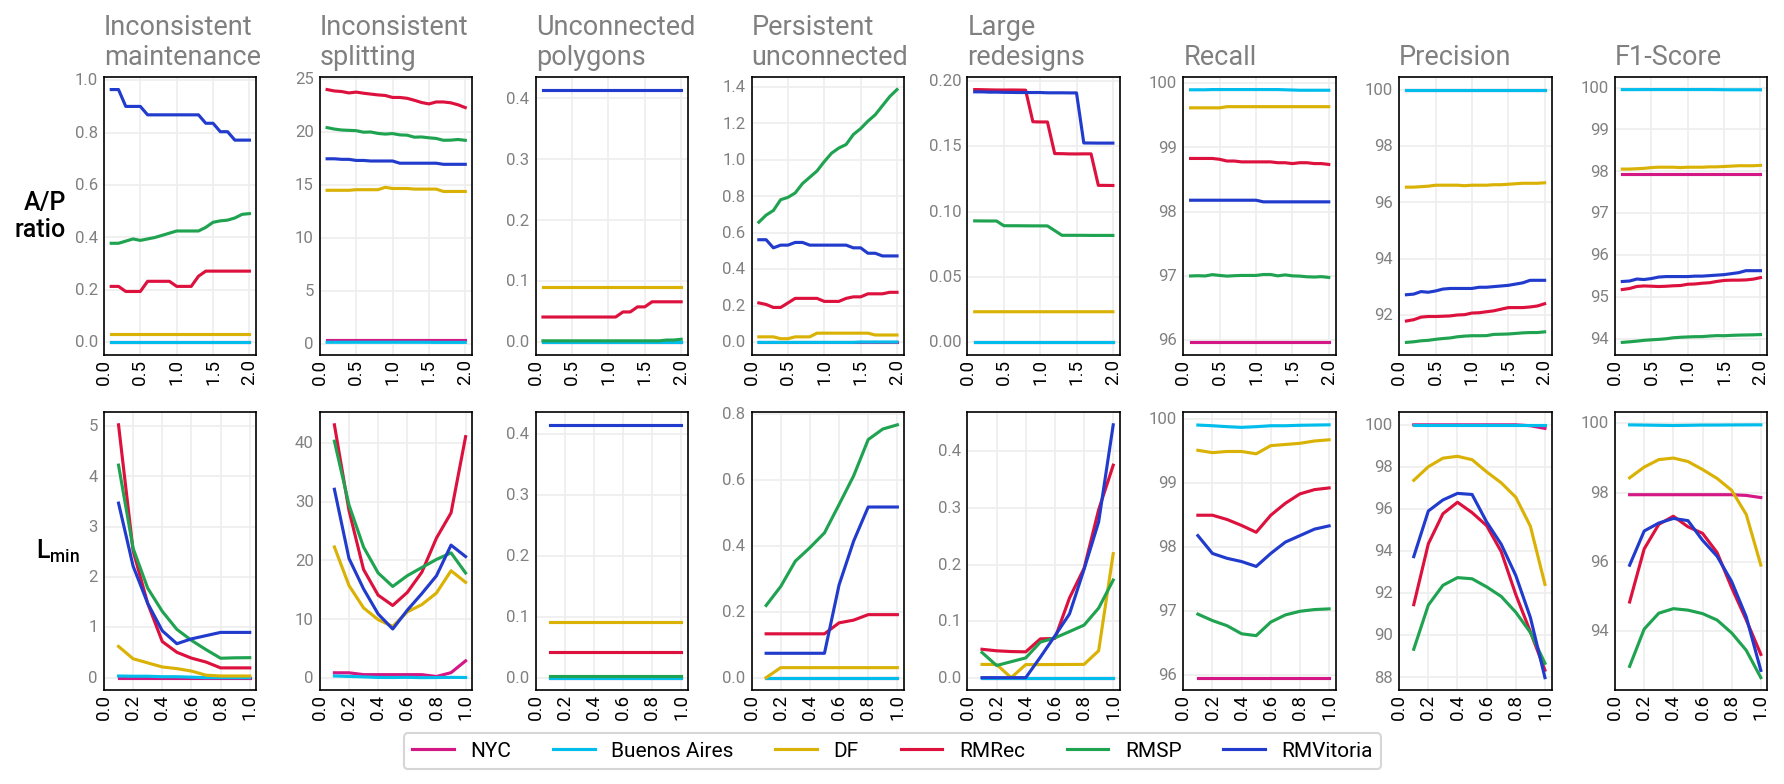

In [231]:
labels = {
    'Inconsistent maintenance': 'Inconsistent\nmaintenance',
    'Inconsistent splitting':'Inconsistent\nsplitting',
    'Unconnected polygons':'Unconnected\npolygons',
    'Persistent unconnected':'Persistent\nunconnected',
    'Large redesigns':'Large\nredesigns',
    'recall': 'Recall',
    'precision': 'Precision',
    'f1_score': 'F1-Score'
    }

colors=["#D31785",
        "#00BDEC", 
        "#DAB205", 
        "#DD113D", 
        "#1FA351", 
        "#213BCC"]

locations = df_apr['location'].unique()
fig, ax = plt.subplots(2,len(labels),figsize=(12, 5), dpi=150,)

for k, c in enumerate([i for i in df_apr.columns if i in labels]):
    i = (0,k)
    group_df = df_apr[['A/P ratio', 'location', c]]
    sns.lineplot(x='A/P ratio',y=c, data=group_df, hue='location', palette=colors, ax=ax[i], marker='None', legend=False)

    ax[i].set_title(labels[c], fontsize=13, ha='left', x=0, color='gray')
    ax[i].xaxis.set_label_text('')

    ax[i].xaxis.set_ticks(group_df['A/P ratio'].drop_duplicates().to_list()[4::5]+[0.0])
    ax[i].tick_params(axis='x', color='white', labelcolor='black', labelsize=9, rotation=90, pad=-2)

    [t.set_color('#aaaaaa') for t in ax[i].yaxis.get_ticklabels()]
    [t.set_va('center') for t in ax[i].yaxis.get_ticklabels()]
    #ax[i].yaxis.set_major_locator(MaxNLocator(integer=True))

    ax[i].tick_params(axis='y', color='white', labelcolor='gray', labelsize=8, pad=-0.5)
    
    ax[i].yaxis.set_label_text('')
    #ax[i].tick_params(axis='y', color='white')

    if k==0:
        ax[i].set_ylabel('A/P\nratio', va='center', ha='right', fontsize=12, fontweight='medium')
        #ax[i].yaxis.set_label_text(r'A/P')
        #ax[i].yaxis.label.set_color('blue')
        ax[i].yaxis.label.set_rotation(0)

    ax[i].grid(axis='y', visible=True, color='#eeeeee')
    ax[i].grid(axis='x', visible=True, color='#eeeeee')
    ax[i].set_facecolor("white")

for k, c in enumerate([i for i in df_lmin.columns if i in labels]):
    i = (1,k)
    group_df = df_lmin[['Lmin', 'location', c]]
    sns.lineplot(x='Lmin',y=c, data=group_df, hue='location', palette=colors, ax=ax[i], marker='None', legend=False)

    #ax[i].set_title(labels[c], fontsize=13, ha='left', x=0)
    ax[i].xaxis.set_label_text('')

    ax[i].xaxis.set_ticks(group_df['Lmin'].drop_duplicates().to_list()[1::2]+[0.0])
    ax[i].tick_params(axis='x', color='white', labelcolor='black', labelsize=9, rotation=90, pad=-2)

    [t.set_color('#aaaaaa') for t in ax[i].yaxis.get_ticklabels()]
    [t.set_va('center') for t in ax[i].yaxis.get_ticklabels()]
    #ax[i].yaxis.set_major_locator(MaxNLocator(integer=True))

    ax[i].tick_params(axis='y', color='white', labelcolor='gray', labelsize=8, pad=-0.5)
    
    ax[i].yaxis.set_label_text('')
    #ax[i].tick_params(axis='y', color='white')

    if k==0:
        ax[i].set_ylabel(r'$L_{min}$',  va='center', ha='right', fontsize=12, fontweight='medium')
        #ax[i].yaxis.set_label_text(r'A/P')
        #ax[i].yaxis.label.set_color('blue')
        ax[i].yaxis.label.set_rotation(0)

    ax[i].grid(axis='y', visible=True, color='#eeeeee')
    ax[i].grid(axis='x', visible=True, color='#eeeeee')
    ax[i].set_facecolor("white")

custom_lines = [Line2D([0], [0], color=colors[0], lw=1.5),
                Line2D([0], [0], color=colors[1], lw=1.5),
                Line2D([0], [0], color=colors[2], lw=1.5),
                Line2D([0], [0], color=colors[3], lw=1.5),
                Line2D([0], [0], color=colors[4], lw=1.5),
                Line2D([0], [0], color=colors[5], lw=1.5)],

fig.tight_layout()
leg = fig.legend(*custom_lines, df_apr['location'].unique(), ncol=len(df_apr['location'].unique()), loc='lower center', bbox_to_anchor=(0.5, -0.05))

plt.savefig(f'docs/metrics.png', bbox_inches='tight')
plt.show()

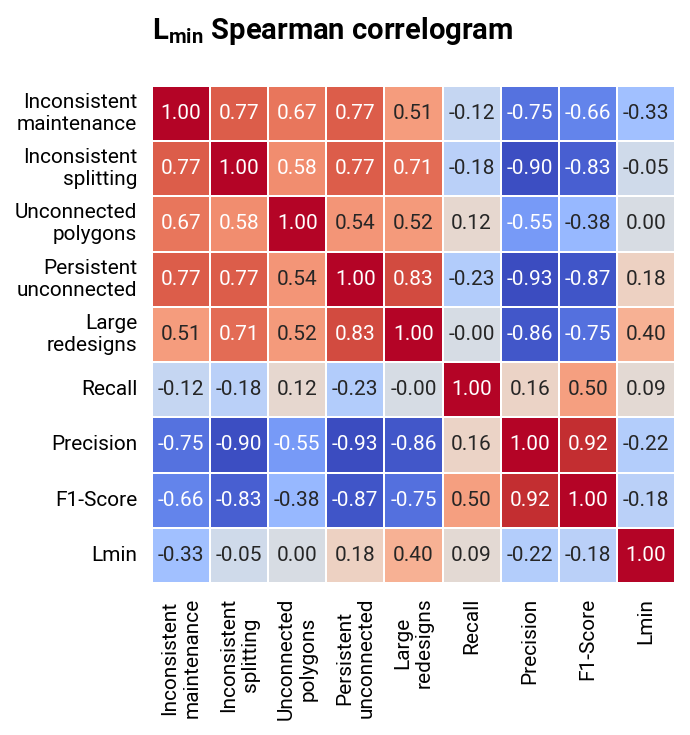

In [237]:
fig, ax = plt.subplots(1,1,figsize=(4.7, 5), dpi=150) # Adjust figure size as needed
sns.heatmap(df_lmin[list(labels.keys())+['Lmin']].rename(columns=labels).corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", ax=ax, linewidth=.1, robust=True, cbar=False)
ax.set_title('$L_{min}$ Spearman correlogram\n', fontsize=14, ha='left', x=0, weight='bold')
ax.tick_params(axis='y', color='white')
ax.tick_params(axis='x', color='white')
fig.tight_layout()
plt.savefig(f'docs/corr-spearman_lmin.png', bbox_inches='tight')
plt.show()

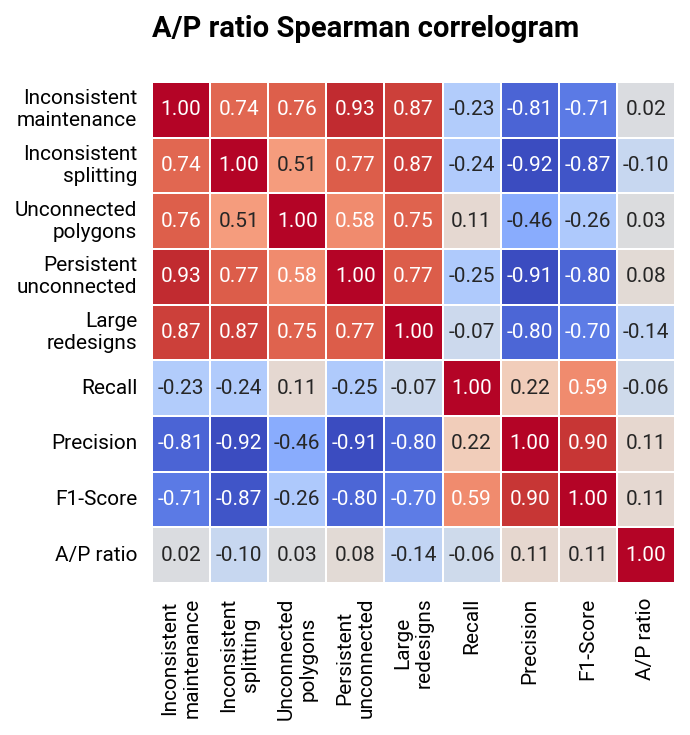

In [238]:
fig, ax = plt.subplots(1,1,figsize=(4.7, 5), dpi=150) # Adjust figure size as needed
sns.heatmap(df_apr[list(labels.keys())+['A/P ratio']].rename(columns=labels).corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", ax=ax, linewidth=.1, robust=True, cbar=False)
ax.set_title('A/P ratio Spearman correlogram\n', fontsize=14, ha='left', x=0, weight='bold')
ax.tick_params(axis='y', color='white')
ax.tick_params(axis='x', color='white')
fig.tight_layout()
plt.savefig(f'docs/corr-spearman_apr.png', bbox_inches='tight')
plt.show()